In [1]:
import numpy as np
import pickle

results = {
  "1A_Small_pretrained_L1loss": "/data/checkpoints/20260127_nested_split/L1_initial_training_smalldataset_FT_OmniLearnedSmall/eval_results/outputs_M1A_L1_pretrainedSmall_minerva_1A_0.npz",
  "1A_Small_L1loss": "/data/checkpoints/20260127_nested_split/L1_initial_training_smalldataset/eval_results/outputs_M1A_L1_minerva_1A_0.npz"
}
results = {
    key: np.load(value)
    for key, value in results.items()
}

In [2]:
results.keys()

dict_keys(['1A_Small_pretrained_L1loss', '1A_Small_L1loss'])

In [3]:
E_true_dict, E_pred_dict = {}, {}
E_pred_over_true_dict = {}
for key in results.keys():
    E_true = results[key]["pid"]
    E_pred = results[key]["prediction"].flatten()
    E_pred_over_true = E_pred / E_true
    E_true_dict[key] = E_true
    E_pred_dict[key] = E_pred_over_true
    E_pred_over_true_dict[key] = E_pred_over_true


1A_Small_pretrained_L1loss RMS: 0.3067109286785126
1A_Small_L1loss RMS: 0.3164055049419403


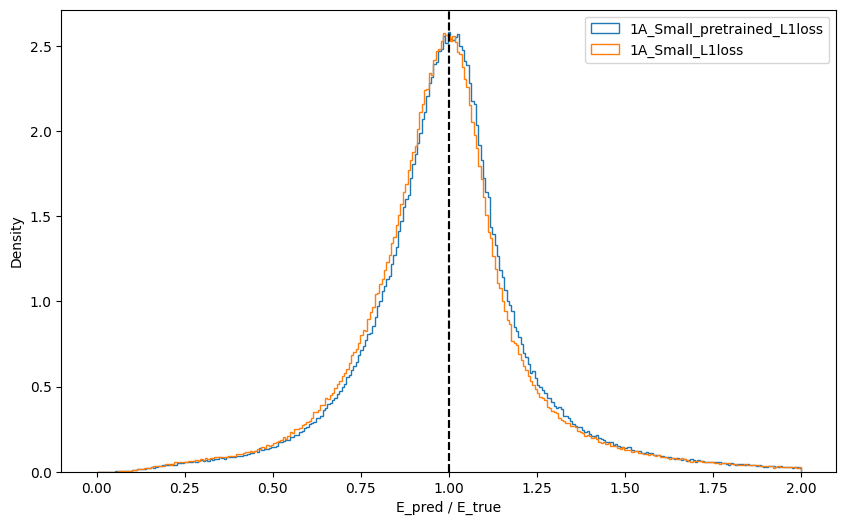

In [4]:
import matplotlib.pyplot as plt
bins = np.linspace(0, 2, 300)
fig, ax = plt.subplots(figsize=(10, 6))
for key in E_pred_over_true_dict.keys():
    ax.hist(E_pred_over_true_dict[key], bins=bins, density=True, histtype="step", label=key)
    # also compute and print RMS
    rms = np.sqrt(np.mean((E_pred_over_true_dict[key] - 1)**2))
    print(f"{key} RMS: {rms}")
    ax.axvline(1, color="black", linestyle="--")
ax.set_xlabel("E_pred / E_true")
ax.set_ylabel("Density")
ax.legend()
fig.show()



In [5]:
split_idx = "/data/Minerva/20260127_nested_split/result.pkl"
split_idx = pickle.load(open(split_idx, "rb"))
split_idx["1A"]["test_idx"]


array([     14,      16,      32, ..., 7601333, 7601343, 7601352])

In [6]:
def get_Enu_fig(mc_E, reco_e_dict: dict):
    # reco_e_dict: key should be what's plotted. value should be same shape as mc_E, if it's not reconstructed, it should have value -1.
    # fig should have 2 x 2 subplots. left: counts; right: normalized histograms to unit area.
    # Top: E / 1000 histograms (GeV); Bottom: E_reco/E_mc
    import numpy as np
    import matplotlib.pyplot as plt
    # make the font of legend a bit smaller

    
    fig, ax = plt.subplots(2, 2, figsize=(12, 12))
    bins_E = np.linspace(0, 20, 200)
    bins_E_reco_over_true = np.linspace(0, 2, 100)
    ax[0, 0].hist(mc_E, bins=bins_E, histtype='step', color='black', label='MC E')
    ax[0, 1].hist(mc_E, bins=bins_E, histtype='step', color='black', label='MC E', density=True)
    
    # Store statistics for text boxes
    stats_text_10 = []  # for ax[1,0]
    stats_text_11 = []  # for ax[1,1]
    
    for method in reco_e_dict.keys():
        mask = reco_e_dict[method] > 0
        percentage_reconstructed = round(np.sum(mask) / len(mask) * 100, 1)
        ax[0, 0].hist(reco_e_dict[method], bins=bins_E, histtype='step', label=method + f" ({percentage_reconstructed}%)")
        ax[0, 1].hist(reco_e_dict[method], bins=bins_E, histtype='step', label=method + f" ({percentage_reconstructed}%)", density=True)
        E_reco_over_true = reco_e_dict[method][mask] / mc_E[mask]
        # MPV (Most Probable Value) - use the bin with max count
        counts, bin_edges = np.histogram(E_reco_over_true, bins=bins_E_reco_over_true)
        mpv_idx = np.argmax(counts)
        mpv = (bin_edges[mpv_idx] + bin_edges[mpv_idx + 1]) / 2
        # Calculate RMS from MPV
        # rms = np.sqrt(np.mean((E_reco_over_true - mpv)**2)) # compute rms from the values bounded by [0, 2]
        mask = (E_reco_over_true >= 0) & (E_reco_over_true <= 2)
        rms = np.sqrt(np.mean((E_reco_over_true[mask] - mpv)**2))
        ax[1, 0].hist(E_reco_over_true, bins=bins_E_reco_over_true, histtype='step', label=method + f" ({percentage_reconstructed}%)")
        ax[1, 1].hist(E_reco_over_true, bins=bins_E_reco_over_true, histtype='step', label=method + f" ({percentage_reconstructed}%)", density=True)
        # Add statistics to text lists
        stats_text_10.append(f"{method}: RMS={rms:.3f}, MPV={mpv:.3f}")
        stats_text_11.append(f"{method}: RMS={rms:.3f}, MPV={mpv:.3f}")
    fontsize_legend= 6.5
    ax[0, 0].legend(fontsize=fontsize_legend)
    ax[0, 0].set_xlabel("Energy [GeV]")
    ax[0, 0].set_ylabel("Counts")
    ax[0, 0].set_title("E nu Distribution")
    ax[0, 1].legend(fontsize=fontsize_legend)
    ax[0, 1].set_xlabel("Energy [GeV]")
    ax[0, 1].set_ylabel("Relative counts")
    ax[0, 1].set_title("E nu Distribution (normalized)")
    ax[1, 0].legend(fontsize=fontsize_legend)
    ax[1, 0].set_xlabel("E reco / E true")
    ax[1, 0].set_ylabel("Counts")
    ax[1, 0].set_title("E reco / E true Distribution")
    ax[1, 1].legend(fontsize=fontsize_legend)
    ax[1, 1].set_xlabel("E reco / E true")
    ax[1, 1].set_ylabel("Relative counts")
    ax[1, 1].set_title("E reco / E true Distribution (normalized)")
    
    # Add statistics text boxes to bottom plots
    stats_text_str_10 = '\n'.join(stats_text_10)
    stats_text_str_11 = '\n'.join(stats_text_11)
    
    ax[1, 0].text(0.98, 0.97, stats_text_str_10, transform=ax[1, 0].transAxes,
                  fontsize=8, verticalalignment='top', horizontalalignment='right',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax[1, 1].text(0.98, 0.97, stats_text_str_11, transform=ax[1, 1].transAxes,
                  fontsize=8, verticalalignment='top', horizontalalignment='right',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Put a grid on all
    ax[0, 0].grid(True)
    ax[0, 1].grid(True)
    ax[1, 0].grid(True)
    ax[1, 1].grid(True)

    # put legends on upper left for bottom plots to avoid overlap with stats
    ax[0, 0].legend(loc='lower right', fontsize=fontsize_legend)
    ax[0, 1].legend(loc='lower right', fontsize=fontsize_legend)
    ax[1, 0].legend(loc='upper left', fontsize=fontsize_legend)
    ax[1, 1].legend(loc='upper left', fontsize=fontsize_legend)
    fig.tight_layout()
    return fig


In [7]:
mc_E = results["1A_Small_L1loss"]["pid"][:37000]

In [8]:
Enu_baselines = "/data/Minerva/20260127_nested_split/enu_baselines/all_playlists_enu_baselines.pkl"
Enu_baselines = pickle.load(open(Enu_baselines, "rb"))

In [9]:
test_baselines = {}
for key in Enu_baselines["1A"].keys():
    if key != "E_muon" and key != "E_true":
        test_baselines[key] = (Enu_baselines["1A"][key][split_idx["1A"]["test_idx"]] / 1000)[:37000]


In [10]:
enu1 = Enu_baselines["1A"]["E_true"][split_idx["1A"]["test_idx"]] / 1000
enu1

array([5.59892021, 3.16205399, 6.86748414, ..., 4.97048614, 7.08359621,
       6.95928271])

In [11]:
mc_E

array([ 5.5989203,  3.162054 ,  6.867484 , ..., 23.996191 , 27.091618 ,
        6.8699956], dtype=float32)

In [12]:
# now also include the model energies as a baseline in the plot
model_energies = results["1A_Small_pretrained_L1loss"]["prediction"].flatten()[:37000]
model_energies_from_scratch = results["1A_Small_L1loss"]["prediction"].flatten()[:37000]

test_baselines["model_energies"] = model_energies
test_baselines["model_energies_from_scratch"] = model_energies_from_scratch



In [13]:
test_baselines.keys()

dict_keys(['CCQE_formula', 'Enu_from_muon', 'Enu_from_muon+proton', 'E_mu+E_recoil', 'E_mu+E_recoil_CCinc', 'model_energies', 'model_energies_from_scratch'])

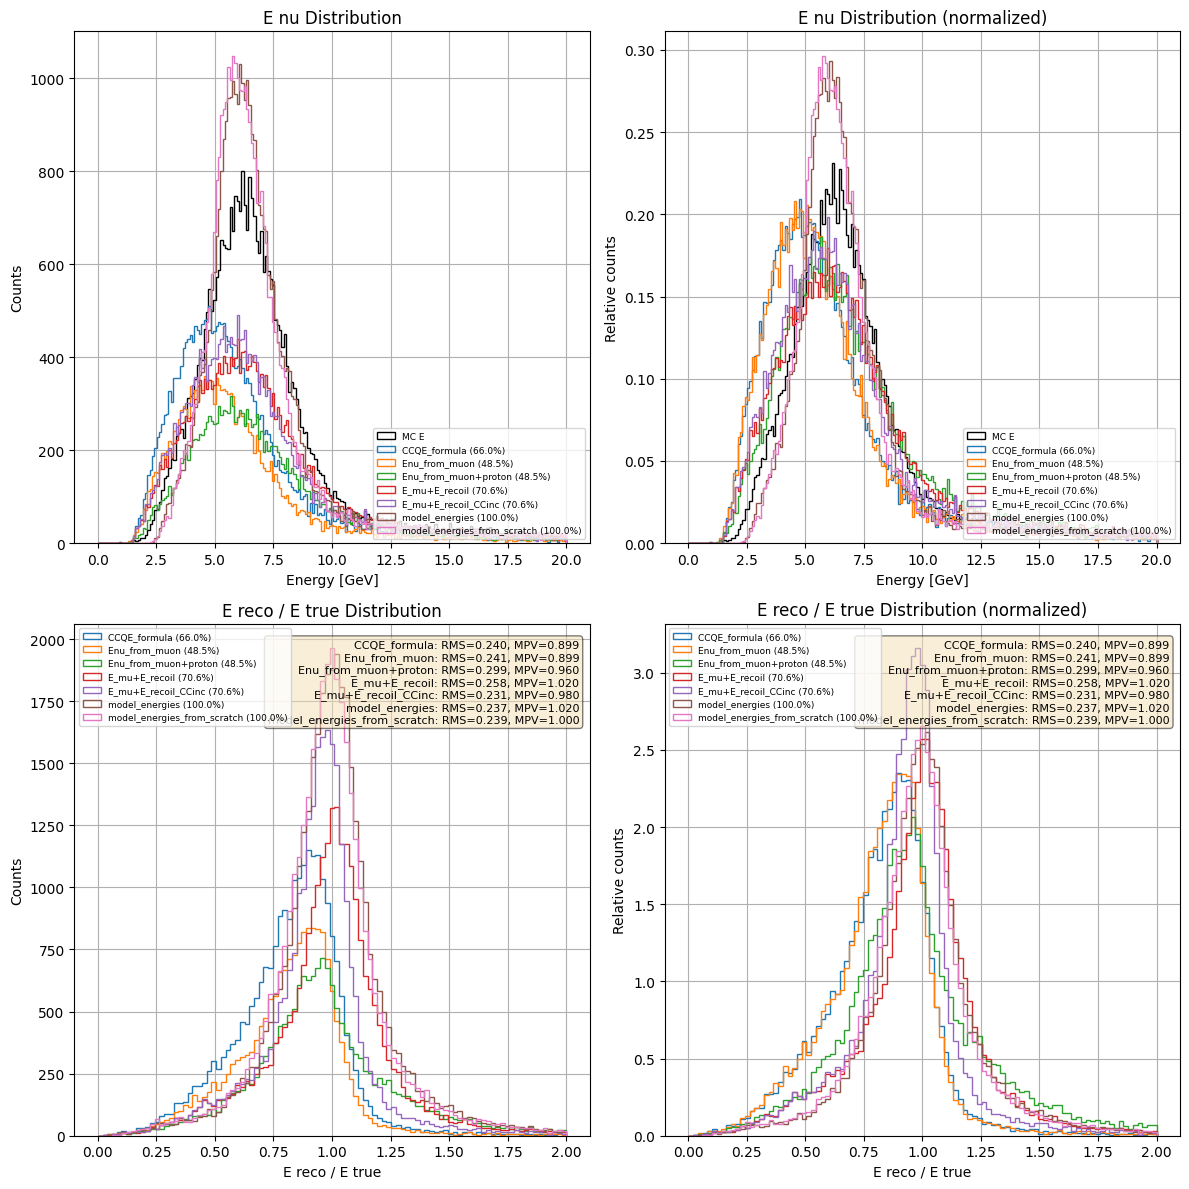

In [14]:
# plot the test baselines using the get_Enu_fig function
fig = get_Enu_fig(mc_E, test_baselines)
fig.show()


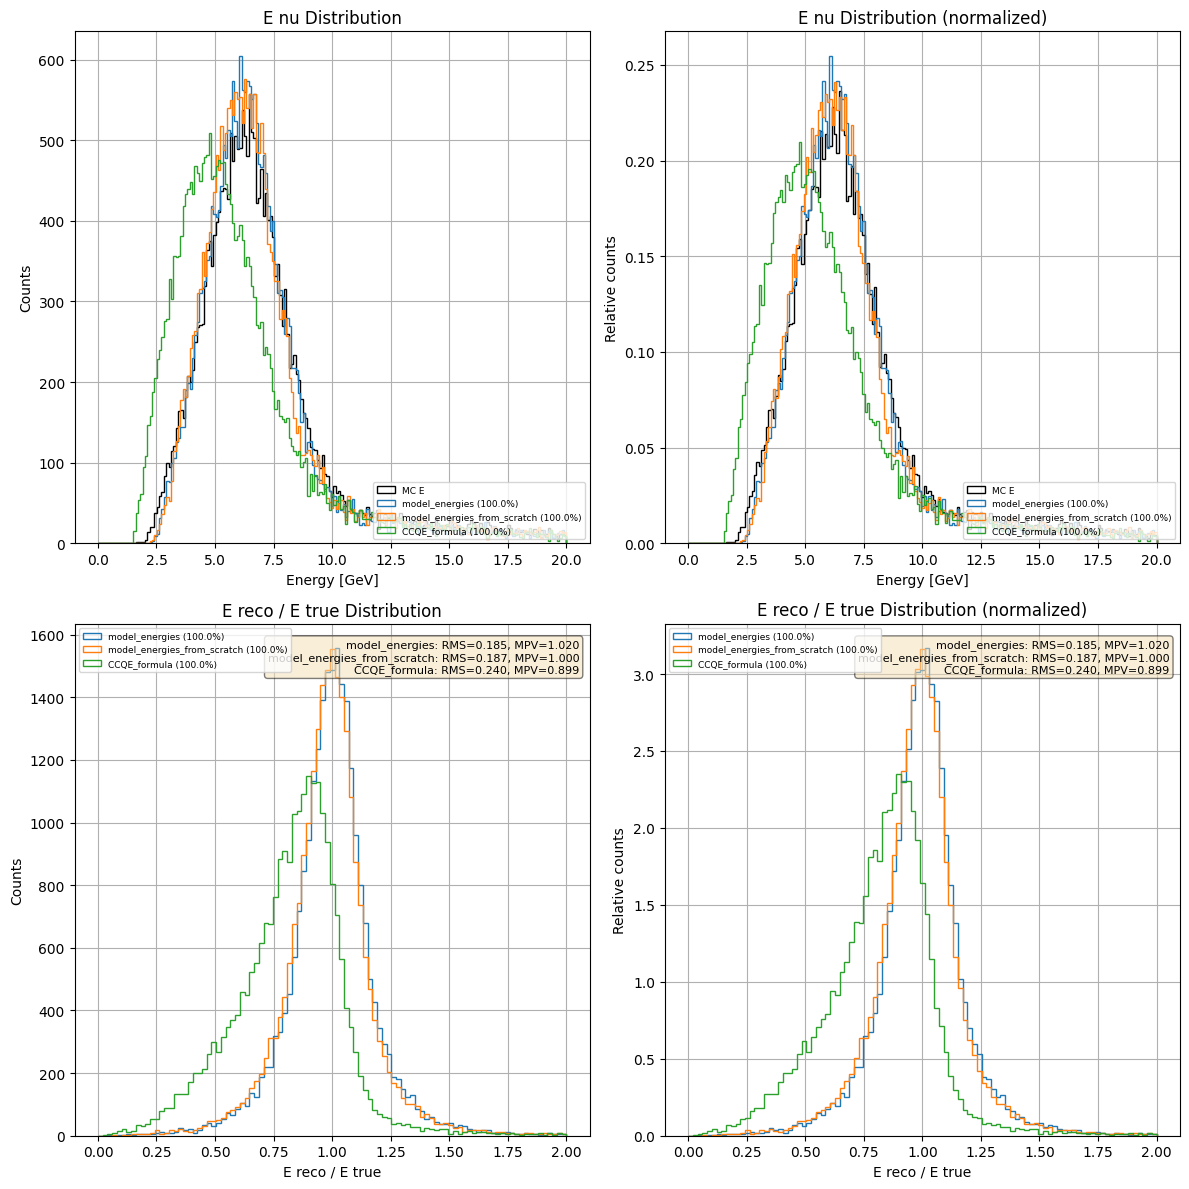

In [15]:
def get_baseline_and_models(mc_E, baseline_dict, baseline_to_pick, model_names=["model_energies", "model_energies_from_scratch"]):
    baseline_E = baseline_dict[baseline_to_pick]
    mask = baseline_E >= 0
    baseline_E = baseline_E[mask]
    mc_E = mc_E[mask]
    output_dict = {}
    for model_name in model_names:
        output_dict[model_name] = baseline_dict[model_name][mask]
    output_dict[baseline_to_pick] = baseline_E
    return mc_E, output_dict

mc_E_filtered, methods_filtered = get_baseline_and_models(mc_E, test_baselines, "CCQE_formula")
fig = get_Enu_fig(mc_E_filtered, methods_filtered).show()


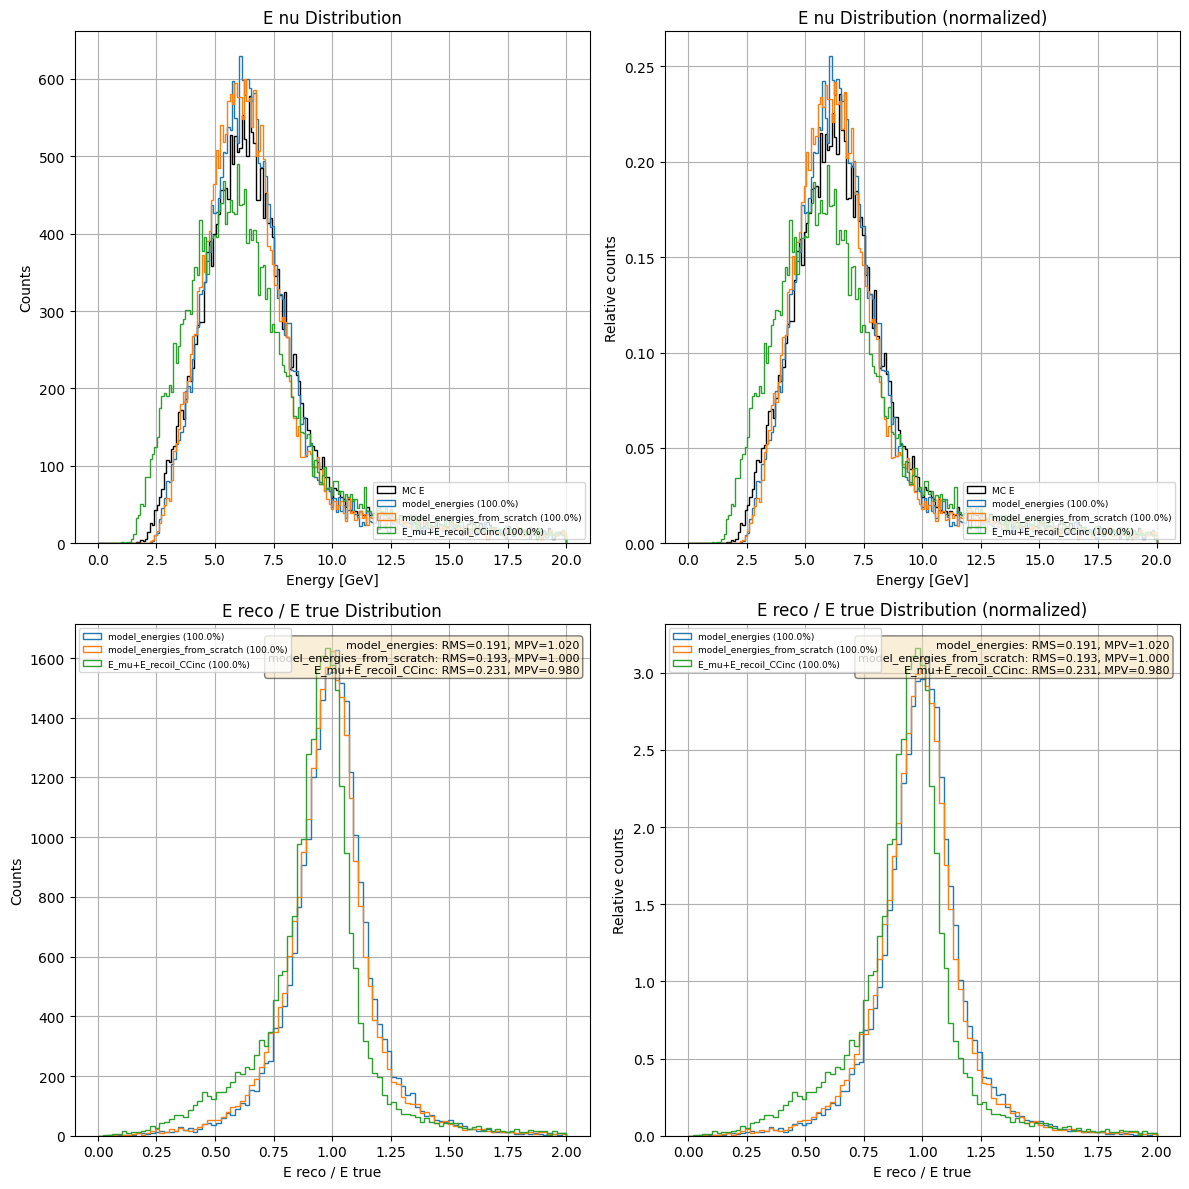

In [16]:
# dict_keys(['CCQE_formula', 'Enu_from_muon', 'Enu_from_muon+proton', 'E_mu+E_recoil', 'E_mu+E_recoil_CCinc', 'model_energies', 'model_energies_from_scratch'])
mc_E_filtered, methods_filtered = get_baseline_and_models(mc_E, test_baselines, "E_mu+E_recoil_CCinc")
fig = get_Enu_fig(mc_E_filtered, methods_filtered).show()
